In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/sp-500-stocks")

print("Path to dataset files:", path)

Path to dataset files: /home/manish/.cache/kagglehub/datasets/andrewmvd/sp-500-stocks/versions/1023


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.cm as cm
from sklearn.model_selection import train_test_split
from statsmodels.tsa.deterministic import DeterministicProcess
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(f"{path}/sp500_index.csv", parse_dates = ["Date"])
df = df.rename(columns={"S&P500": "Price"})
df = df.set_index("Date")
df = df.to_period("D")
df.head(5)

/home/manish/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/home/manish/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


,Price
Date,
2014-12-22,2078.54
2014-12-23,2082.17
2014-12-24,2081.88
2014-12-26,2088.77
2014-12-29,2090.57


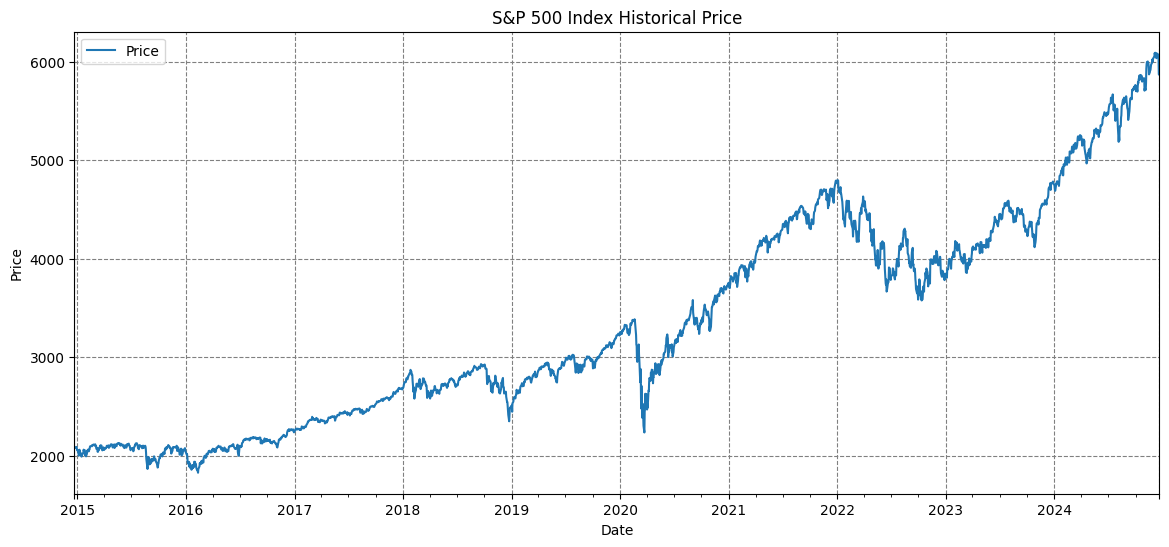

In [3]:
df["Price"].plot(figsize=(14, 6))
plt.title("S&P 500 Index Historical Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(color="gray", linestyle="--")
plt.show()

## Adding deterministic process
this will essentially be the constant and trend features that will be used for future models

In [4]:
dp = DeterministicProcess(
    index=df.index,
    constant=True,
    order=1,
    drop=True,
)

X = dp.in_sample()

X.head()

,const,trend
Date,,
2014-12-22,1.0,1.0
2014-12-23,1.0,2.0
2014-12-24,1.0,3.0
2014-12-26,1.0,4.0
2014-12-29,1.0,5.0


## This is moving average

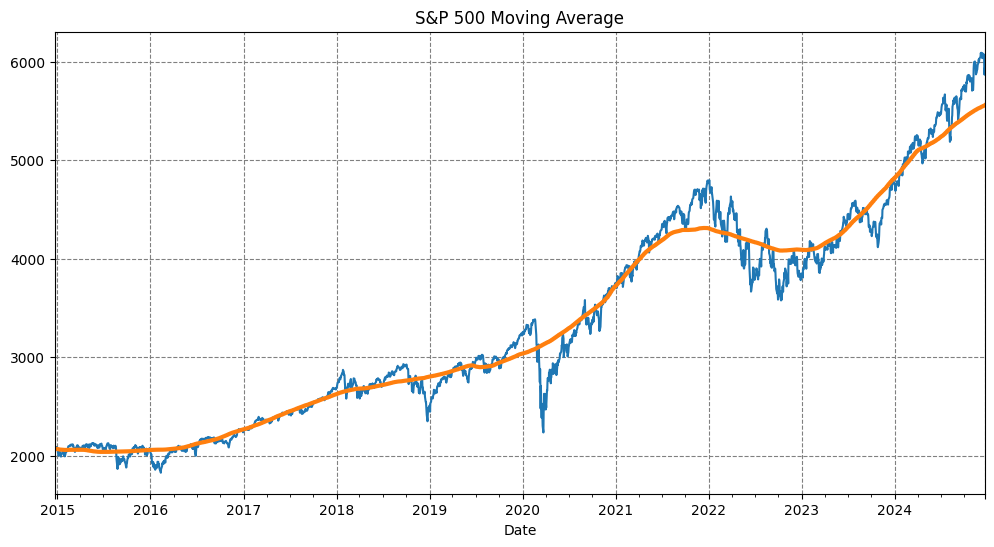

In [5]:
moving_average = df.rolling(
    window=365,
    center=True,
    min_periods=183,
).mean()



ax = df["Price"].plot(title="S&P 500 Moving Average")
ax = moving_average.plot(ax=ax, label="Moving Average", linewidth=3, figsize=(12, 6), legend=False)
plt.grid(color="gray", linestyle="--")

In [6]:
y = df.loc[:, "Price"]

model = LinearRegression()
model.fit(X, y)

y_pred = pd.Series(model.predict(X), index=X.index)

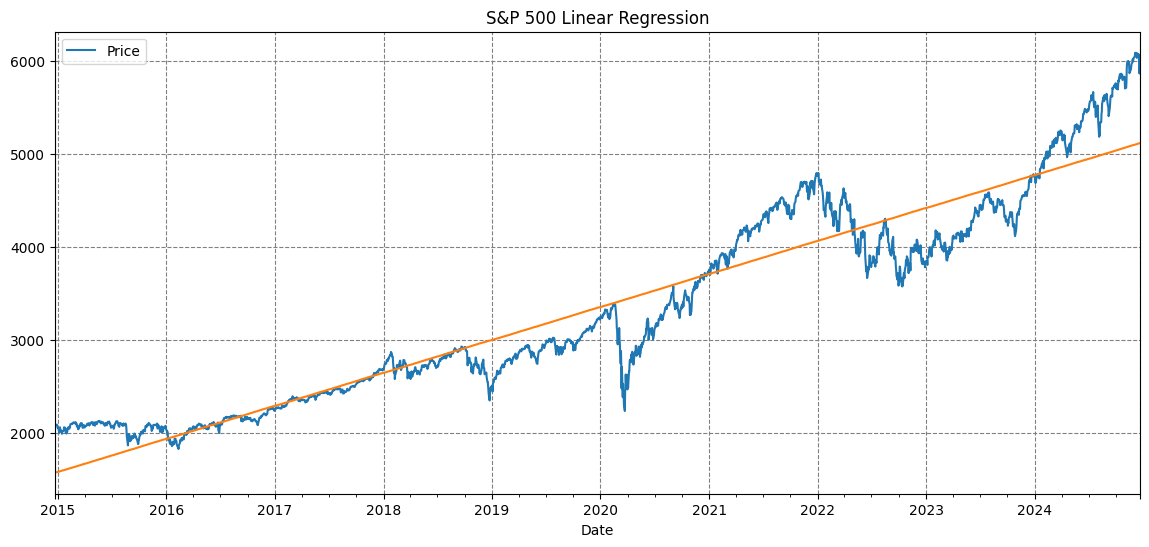

In [7]:
ax = df.plot()
_ = y_pred.plot(ax=ax, label="Trend", figsize=(14, 6), title="S&P 500 Linear Regression")
plt.grid(color="gray", linestyle="--")

The linear regression model can be utilized to make forecasts by producing deterministic trends outside of the time period that it has been trained upon. In this case, it will be extrapolated by 365 steps or an entire year.

In [8]:
X = dp.out_of_sample(steps=365)

y_fore = pd.Series(model.predict(X), index=X.index)

y_fore.head()


2024-12-21    5120.233420
2024-12-22    5121.642381
2024-12-23    5123.051341
2024-12-24    5124.460302
2024-12-25    5125.869263
Freq: D, dtype: float64

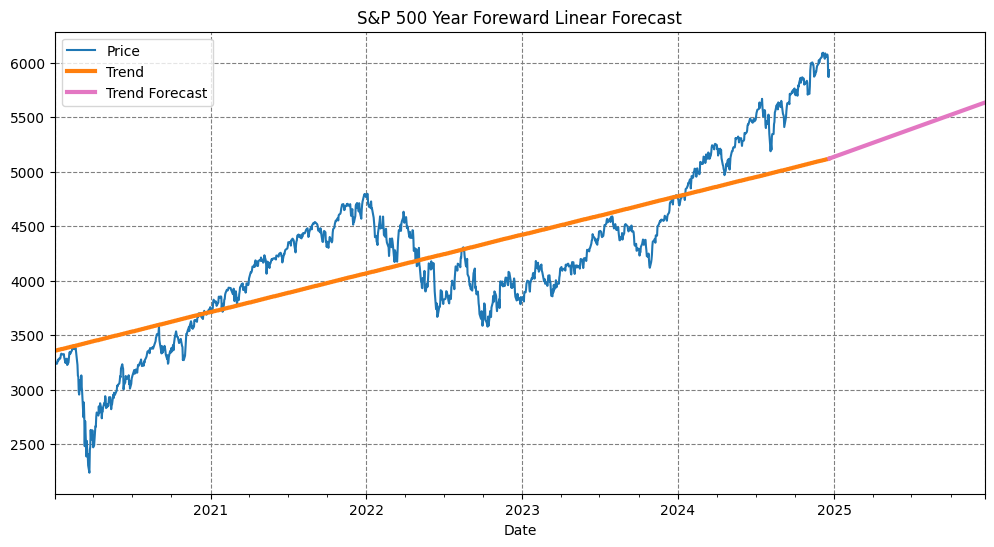

In [9]:
ax = df["2020":].plot(title="S&P 500 Year Foreward Linear Forecast")
ax = y_pred["2020":].plot(ax=ax, linewidth=3, label="Trend")
ax = y_fore.plot(ax=ax, linewidth=3, label="Trend Forecast", color="C6", figsize=(12, 6))
_ = ax.legend()
plt.grid(color="gray", linestyle="--")

## Multi Output Strategy

Lag values are values from before the current value, essentially the past value of what's presently being observed (Haden, 2025). For instance, a one-day lag feature can be a copied column in a dataset that is one day late from the original column; they can be helpful in identifying patterns and feature engineering, wherein they can add more potential insights to the already present information. They will be used here to synthesize more data for a Multi-output strategy, utilizing a model that produces multiple outputs, such as linear regression. Thirty lags would be created to be added to the dataset, which will be trained and tested by the model to forecast thirty days from each datum into the future.

In [10]:
def make_lags(ts, lags, lead_time=1):
    return pd.concat(
        {
            f"y_lag_{i}": ts.shift(i)
            for i in range(lead_time, lags + lead_time)
        },
        axis=1)


y = df["Price"]
X = make_lags(y, lags=30).fillna(0.0)


def make_multistep_target(ts, steps):
    return pd.concat(
        {f"y_step_{i + 1}": ts.shift(-i)
         for i in range(steps)},
        axis=1)

y = make_multistep_target(y, steps=30).dropna()

y, X = y.align(X, join="inner", axis=0)

## Autocorrelation

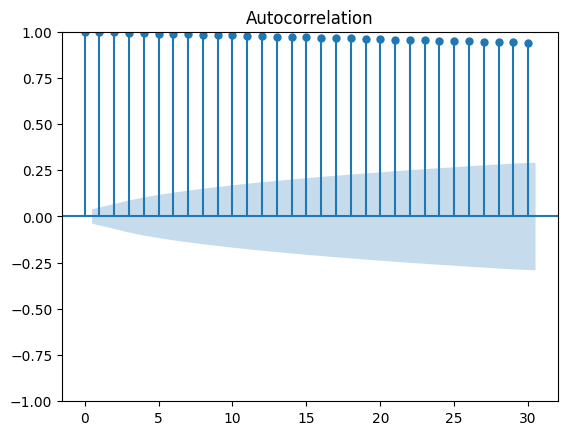

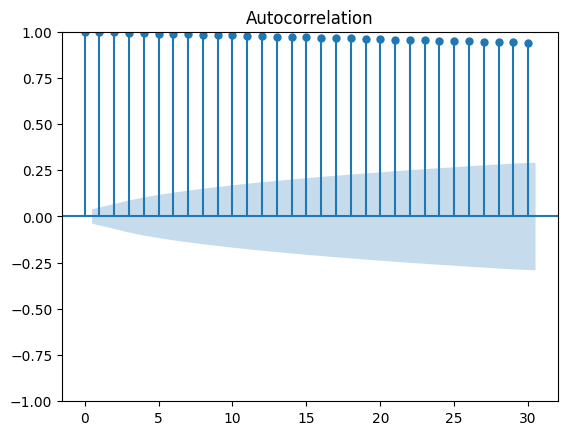

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df['Price'], lags=30)

In [12]:
y.head()

,y_step_1,y_step_2,y_step_3,y_step_4,y_step_5,y_step_6,y_step_7,y_step_8,y_step_9,y_step_10,...,y_step_21,y_step_22,y_step_23,y_step_24,y_step_25,y_step_26,y_step_27,y_step_28,y_step_29,y_step_30
Date,,,,,,,,,,,,,,,,,,,,,
2014-12-22,2078.54,2082.17,2081.88,2088.77,2090.57,2080.35,2058.90,2058.20,2020.58,2002.61,...,2063.15,2051.82,2057.09,2029.55,2002.16,2021.25,1994.99,2020.85,2050.03,2041.51
2014-12-23,2082.17,2081.88,2088.77,2090.57,2080.35,2058.90,2058.20,2020.58,2002.61,2025.90,...,2051.82,2057.09,2029.55,2002.16,2021.25,1994.99,2020.85,2050.03,2041.51,2062.52
2014-12-24,2081.88,2088.77,2090.57,2080.35,2058.90,2058.20,2020.58,2002.61,2025.90,2062.14,...,2057.09,2029.55,2002.16,2021.25,1994.99,2020.85,2050.03,2041.51,2062.52,2055.47
2014-12-26,2088.77,2090.57,2080.35,2058.90,2058.20,2020.58,2002.61,2025.90,2062.14,2044.81,...,2029.55,2002.16,2021.25,1994.99,2020.85,2050.03,2041.51,2062.52,2055.47,2046.74
2014-12-29,2090.57,2080.35,2058.90,2058.20,2020.58,2002.61,2025.90,2062.14,2044.81,2028.26,...,2002.16,2021.25,1994.99,2020.85,2050.03,2041.51,2062.52,2055.47,2046.74,2068.59


In [13]:
X.head()

,y_lag_1,y_lag_2,y_lag_3,y_lag_4,y_lag_5,y_lag_6,y_lag_7,y_lag_8,y_lag_9,y_lag_10,...,y_lag_21,y_lag_22,y_lag_23,y_lag_24,y_lag_25,y_lag_26,y_lag_27,y_lag_28,y_lag_29,y_lag_30
Date,,,,,,,,,,,,,,,,,,,,,
2014-12-22,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-12-23,2078.54,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-12-24,2082.17,2078.54,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-12-26,2081.88,2082.17,2078.54,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-12-29,2088.77,2081.88,2082.17,2078.54,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
print(X.shape)
print(y.shape)

(2488, 30)
(2488, 30)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=False)

model = LinearRegression()
model.fit(X_train, y_train)

y_fit = pd.DataFrame(model.predict(X_train), index=X_train.index, columns=y.columns)
y_pred = pd.DataFrame(model.predict(X_test), index=X_test.index, columns=y.columns)

In [16]:
# For older versions (< 1.0), calculate RMSE manually
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate MSE first, then take sqrt for RMSE
train_mse = mean_squared_error(y_train, y_fit)
train_rmse = np.sqrt(train_mse)

test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE:  {test_rmse:.2f}")
print(f"MAE:        {mae:.2f}")
print(f"R²:         {r2:.4f}")

Train RMSE: 129.99
Test RMSE:  171.39
MAE:        137.65
R²:         0.9350


## MultiOutput Results

The evaluation comes from the test predictions and is measured in root mean squared error, how far off the predictions are; mean absolute error, the average magnitude of the errors; and the coefficient of determination, the amount of variation in the true values that is explained by the model.

The multioutput linear regression model shows strong performance with a test RMSE of 163.47, indicating a moderate average error in predictions. The MAE of 137.65 suggests that errors are fairly consistent across the predictions. The R² value of 0.9350 indicates that the model explains about 93.5% of the variance in the data.

In [17]:
def plot_multistep(y, every=1, ax=None, palette_kwargs=None):
    palette_kwargs_ = dict(palette="husl", n_colors=16, desat=None)
    if palette_kwargs is not None:
        palette_kwargs_.update(palette_kwargs)
    palette = sns.color_palette(**palette_kwargs_)
    if ax is None:
        fig, ax = plt.subplots()
    ax.set_prop_cycle(plt.cycler("color", palette))
    for date, preds in y[::every].iterrows():
        preds.index = pd.period_range(start=date, periods=len(preds))
        preds.plot(ax=ax)
    return ax

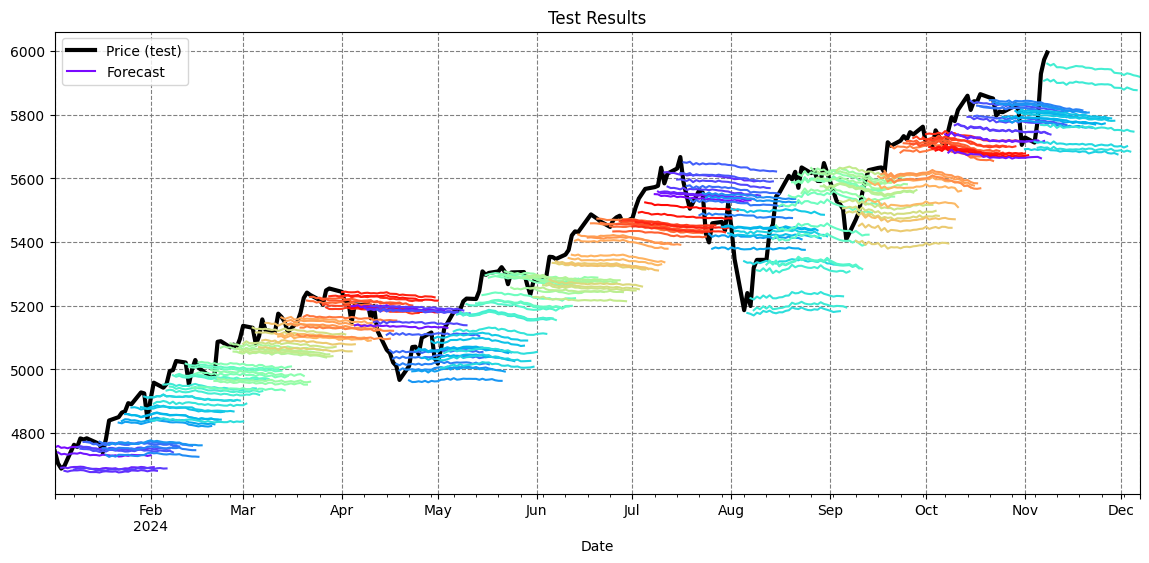

In [18]:
df_filtered = df[df.index >= "2020"]
y_pred_filtered = y_pred[y_pred.index >= "2024"]

fig, ax = plt.subplots(figsize=(14, 6))

ax = df_filtered["Price"][y_pred_filtered.index].plot(ax=ax, color="black", linewidth=3)
ax = plot_multistep(y_pred_filtered, ax=ax, palette_kwargs=dict(palette="rainbow", n_colors=64))

ax.legend(["Price (test)", "Forecast"])
ax.set_title("Test Results")
plt.grid(color="gray", linestyle="--")

plt.show()

In [19]:
import torch

def ensure_datetime(date_obj):
    if isinstance(date_obj, pd.Period):
        return date_obj.to_timestamp()
    return date_obj

if isinstance(df.index, pd.PeriodIndex):
    df.index = df.index.to_timestamp()

dates = df.index

prices = df["Price"].values.reshape(-1, 1)
scaler = MinMaxScaler()
prices_scaled = scaler.fit_transform(prices)

def create_sequences(data, dates, input_len=60, output_len=7):
    X, y = [], []
    X_dates, y_dates = [], []
    
    for i in range(len(data) - input_len - output_len):
        X.append(data[i:i+input_len])
        y.append(data[i+input_len:i+input_len+output_len])
        
        X_dates.append(dates[i+input_len])
        y_dates.append(dates[i+input_len:i+input_len+output_len])
        
    return torch.tensor(X), torch.tensor(y), X_dates, y_dates
X, y, X_dates, y_dates = create_sequences(prices_scaled, dates, input_len=60, output_len=30)

/tmp/ipykernel_24456/2715680983.py:28: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  return torch.tensor(X), torch.tensor(y), X_dates, y_dates


In [20]:
split = int(0.75 * len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

In [21]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([1820, 60, 1]) torch.Size([1820, 30, 1])
torch.Size([607, 60, 1]) torch.Size([607, 30, 1])


In [22]:
# Saving the train and test files for future useimport pickle
import pickle
# Save to pickle file
data_to_save = {
    'X_train': X_train,
    'y_train': y_train,
    'X_test': X_test,
    'y_test': y_test
}

# Save
with open('sp500_data.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)

print("Data saved to 'sp500_data.pkl'")

Data saved to 'sp500_data.pkl'


## RNN, GRU and LSTM

Starting model training...
Data shapes:
X_train: torch.Size([1820, 60, 1]), y_train: torch.Size([1820, 30, 1])
X_test: torch.Size([607, 60, 1]), y_test: torch.Size([607, 30, 1])

Starting training for RNN...

Training RNN
Using device: cpu
Epoch    0: Train RMSE: 0.0465, Test RMSE: 0.0830, LR: 0.001000
Early stopping at epoch 57

RNN Final Results:
Train RMSE: 0.039065
Test RMSE:  0.052642

Starting training for GRU...

Training GRU
Using device: cpu
Epoch    0: Train RMSE: 0.0714, Test RMSE: 0.0598, LR: 0.001000
Early stopping at epoch 81

GRU Final Results:
Train RMSE: 0.031196
Test RMSE:  0.043879

Starting training for LSTM...

Training LSTM
Using device: cpu
Epoch    0: Train RMSE: 0.0905, Test RMSE: 0.1372, LR: 0.001000
Early stopping at epoch 75

LSTM Final Results:
Train RMSE: 0.030809
Test RMSE:  0.071875


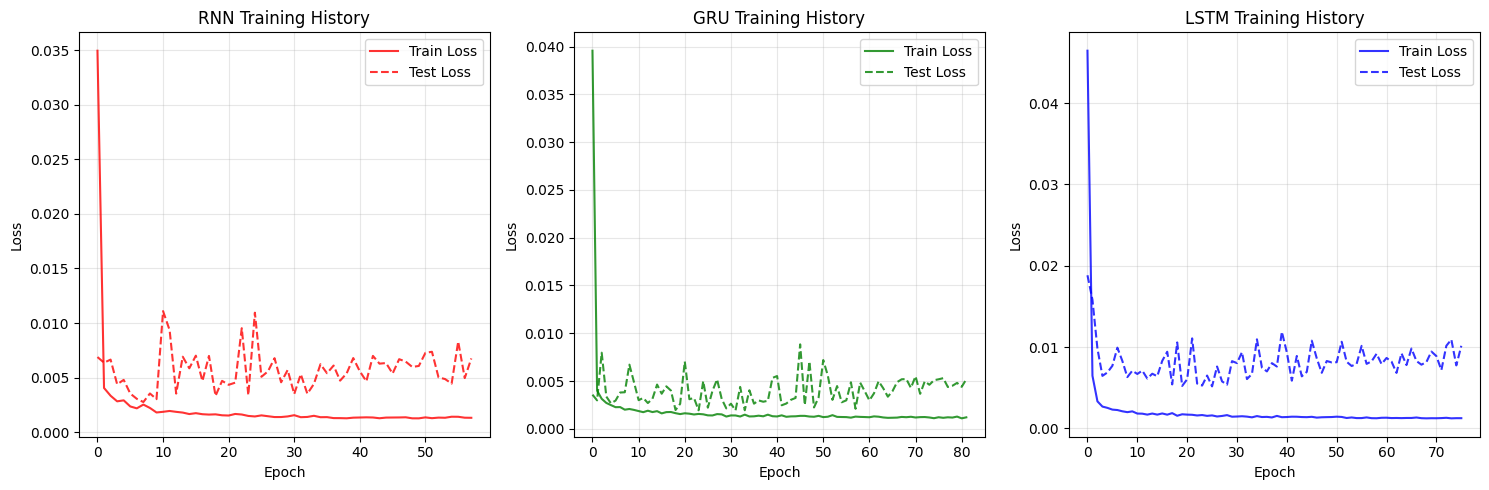


MODEL PERFORMANCE COMPARISON


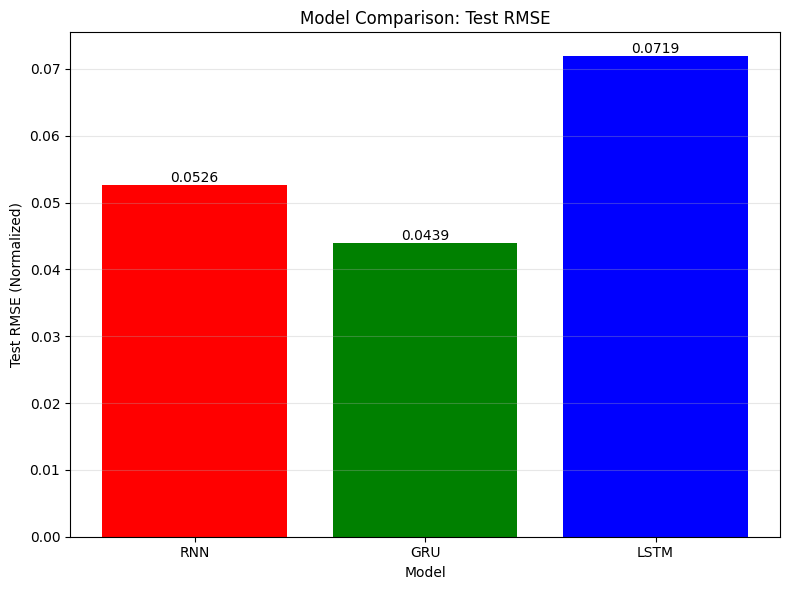

RNN: Test RMSE = 0.052642
GRU: Test RMSE = 0.043879
LSTM: Test RMSE = 0.071875

Best model: GRU (RMSE: 0.043879)


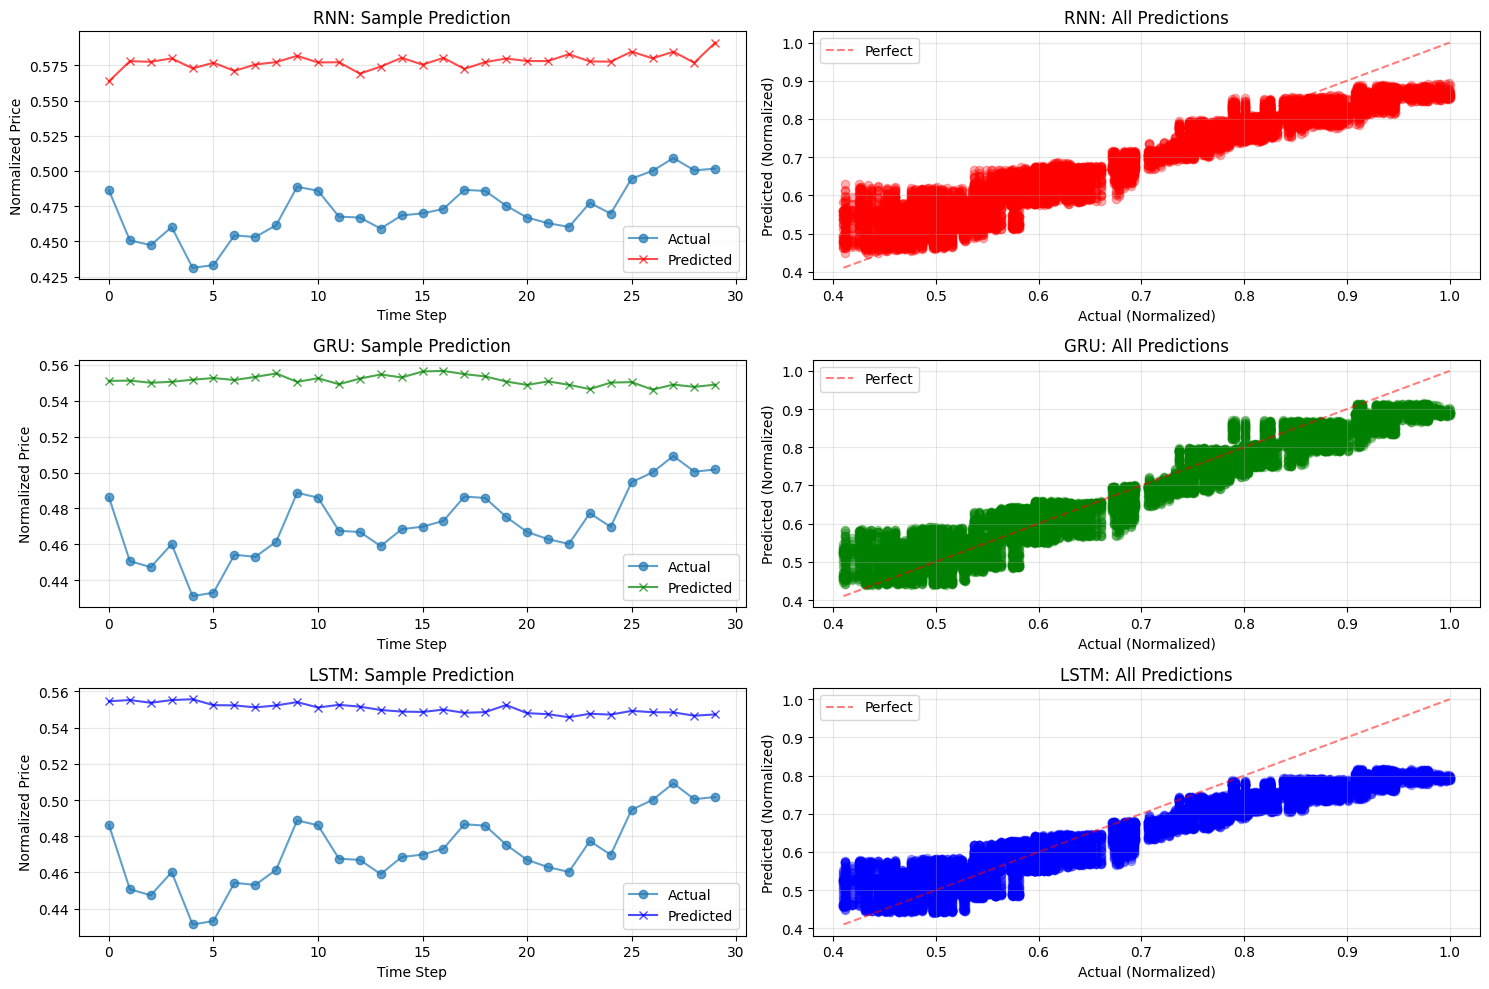

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# ============================================================================
# 1. RNN Model (Simple Recurrent Network)
# ============================================================================

class SimpleRNNModel(nn.Module):
    def __init__(self, input_len=60, output_len=30):
        super().__init__()
        self.input_len = input_len
        self.output_len = output_len
        
        # RNN layer
        self.rnn = nn.RNN(
            input_size=1, 
            hidden_size=50, 
            num_layers=2, 
            batch_first=True, 
            dropout=0.2,
            nonlinearity='tanh'
        )
        
        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Linear(50, 100),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(100, output_len)
        )
    
    def forward(self, x):
        # x shape: [batch_size, input_len, 1]
        rnn_out, hidden = self.rnn(x)
        last_hidden = hidden[-1]
        predictions = self.fc(last_hidden)
        return predictions.unsqueeze(-1)

# ============================================================================
# 2. GRU Model (Gated Recurrent Unit)
# ============================================================================

class SimpleGRUModel(nn.Module):
    def __init__(self, input_len=60, output_len=30):
        super().__init__()
        self.input_len = input_len
        self.output_len = output_len
        
        # GRU layer
        self.gru = nn.GRU(
            input_size=1, 
            hidden_size=50, 
            num_layers=2, 
            batch_first=True, 
            dropout=0.2
        )
        
        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Linear(50, 100),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(100, output_len)
        )
    
    def forward(self, x):
        # x shape: [batch_size, input_len, 1]
        gru_out, hidden = self.gru(x)
        last_hidden = hidden[-1]
        predictions = self.fc(last_hidden)
        return predictions.unsqueeze(-1)

# ============================================================================
# 3. LSTM Model (Your existing model)
# ============================================================================

class SimpleLSTMModel(nn.Module):
    def __init__(self, input_len=60, output_len=30):
        super().__init__()
        self.input_len = input_len
        self.output_len = output_len
        
        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=1, 
            hidden_size=50, 
            num_layers=2, 
            batch_first=True, 
            dropout=0.2
        )
        
        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Linear(50, 100),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(100, output_len)
        )
    
    def forward(self, x):
        # x shape: [batch_size, input_len, 1]
        lstm_out, (hidden, cell) = self.lstm(x)
        last_hidden = hidden[-1]
        predictions = self.fc(last_hidden)
        return predictions.unsqueeze(-1)

# ============================================================================
# 4. Training Function (Fixed version)
# ============================================================================

def train_model(model, model_name, X_train, y_train, X_test, y_test, 
                n_epochs=1000, lr=0.001, batch_size=32, patience=100):
    """
    Generic training function for RNN/LSTM/GRU models
    """
    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}")
    
    # Move to device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    model = model.to(device)
    X_train = X_train.float().to(device)
    y_train = y_train.float().to(device)
    X_test = X_test.float().to(device)
    y_test = y_test.float().to(device)
    
    # Optimizer
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # FIXED: Removed verbose parameter
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=patience//2, factor=0.5
    )
    
    # Loss function
    loss_fn = nn.MSELoss()
    
    # Data loader
    train_dataset = data.TensorDataset(X_train, y_train)
    loader = data.DataLoader(
        train_dataset, 
        shuffle=True, 
        batch_size=batch_size,
        drop_last=False
    )
    
    # Training tracking
    best_test_loss = float('inf')
    patience_counter = 0
    train_losses = []
    test_losses = []
    
    for epoch in range(n_epochs):
        # Training
        model.train()
        train_loss = 0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            train_loss += loss.item()
        
        avg_train_loss = train_loss / len(loader)
        train_losses.append(avg_train_loss)
        
        # Validation
        model.eval()
        with torch.no_grad():
            y_pred_test = model(X_test)
            test_loss = loss_fn(y_pred_test, y_test)
            test_rmse = torch.sqrt(test_loss)
            test_losses.append(test_loss.item())
        
        # Learning rate scheduling
        scheduler.step(test_loss)
        
        # Early stopping check
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            patience_counter = 0
            # Save best model
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': best_test_loss,
            }, f'best_{model_name.lower()}.pth')
        else:
            patience_counter += 1
        
        # Print progress
        if epoch % 100 == 0:
            with torch.no_grad():
                y_pred_train = model(X_train)
                train_rmse = torch.sqrt(loss_fn(y_pred_train, y_train))
            print(f"Epoch {epoch:4d}: Train RMSE: {train_rmse:.4f}, "
                  f"Test RMSE: {test_rmse:.4f}, "
                  f"LR: {optimizer.param_groups[0]['lr']:.6f}")
        
        # Early stopping
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break
    
    # Load best model
    checkpoint = torch.load(f'best_{model_name.lower()}.pth', 
                           map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # Final evaluation
    model.eval()
    with torch.no_grad():
        y_pred_train = model(X_train)
        y_pred_test = model(X_test)
        
        train_rmse = torch.sqrt(loss_fn(y_pred_train, y_train)).item()
        test_rmse = torch.sqrt(loss_fn(y_pred_test, y_test)).item()
    
    print(f"\n{model_name} Final Results:")
    print(f"Train RMSE: {train_rmse:.6f}")
    print(f"Test RMSE:  {test_rmse:.6f}")
    
    return model, train_losses, test_losses, y_pred_test

# ============================================================================
# 5. Main Execution
# ============================================================================

def main():
    # Assuming df is already loaded
    print("Data shapes:")
    print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")
    
    # Define models to train
    models_to_train = {
        'RNN': SimpleRNNModel(input_len=60, output_len=30),
        'GRU': SimpleGRUModel(input_len=60, output_len=30),
        'LSTM': SimpleLSTMModel(input_len=60, output_len=30)
    }
    
    # Train all models
    results = {}
    for model_name, model in models_to_train.items():
        print(f"\nStarting training for {model_name}...")
        trained_model, train_losses, test_losses, y_pred_test = train_model(
            model=model,
            model_name=model_name,
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test,
            n_epochs=500,  # Reduced for testing
            lr=0.001,
            batch_size=32,
            patience=50
        )
        results[model_name] = (trained_model, train_losses, test_losses, y_pred_test)
    
    # Plot training curves
    plt.figure(figsize=(15, 5))
    
    colors = {'RNN': 'red', 'GRU': 'green', 'LSTM': 'blue'}
    
    for idx, (model_name, (_, train_losses, test_losses, _)) in enumerate(results.items()):
        plt.subplot(1, 3, idx+1)
        plt.plot(train_losses, label='Train Loss', color=colors[model_name], alpha=0.8)
        plt.plot(test_losses, label='Test Loss', color=colors[model_name], 
                linestyle='--', alpha=0.8)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title(f'{model_name} Training History')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Compare test RMSE
    print(f"\n{'='*60}")
    print("MODEL PERFORMANCE COMPARISON")
    print(f"{'='*60}")
    
    loss_fn = nn.MSELoss()
    test_rmses = {}
    
    for model_name, (_, _, _, y_pred_test) in results.items():
        with torch.no_grad():
            test_loss = loss_fn(y_pred_test, y_test)
            test_rmse = torch.sqrt(test_loss).item()
            test_rmses[model_name] = test_rmse
    
    # Plot bar chart
    plt.figure(figsize=(8, 6))
    bars = plt.bar(test_rmses.keys(), test_rmses.values(), 
                   color=[colors[name] for name in test_rmses.keys()])
    plt.xlabel('Model')
    plt.ylabel('Test RMSE (Normalized)')
    plt.title('Model Comparison: Test RMSE')
    plt.grid(True, alpha=0.3, axis='y')
    
    # Add values on bars
    for bar, (model_name, rmse) in zip(bars, test_rmses.items()):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{rmse:.4f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Print results
    for model_name, rmse in test_rmses.items():
        print(f"{model_name}: Test RMSE = {rmse:.6f}")
    
    # Best model
    best_model_name = min(test_rmses, key=test_rmses.get)
    print(f"\nBest model: {best_model_name} (RMSE: {test_rmses[best_model_name]:.6f})")
    
    # Plot sample predictions from each model
    plt.figure(figsize=(15, 10))
    
    for idx, (model_name, (_, _, _, y_pred_test)) in enumerate(results.items()):
        plt.subplot(3, 2, 2*idx+1)
        
        # Sample prediction
        sample_idx = 0
        actual = y_test[sample_idx, :, 0].cpu().numpy()
        predicted = y_pred_test[sample_idx, :, 0].cpu().numpy()
        
        plt.plot(actual, label='Actual', marker='o', alpha=0.7)
        plt.plot(predicted, label='Predicted', marker='x', 
                color=colors[model_name], alpha=0.7)
        plt.xlabel('Time Step')
        plt.ylabel('Normalized Price')
        plt.title(f'{model_name}: Sample Prediction')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Scatter plot for all predictions
        plt.subplot(3, 2, 2*idx+2)
        
        all_actual = y_test[:, :, 0].cpu().numpy().flatten()
        all_pred = y_pred_test[:, :, 0].cpu().numpy().flatten()
        
        plt.scatter(all_actual, all_pred, alpha=0.3, color=colors[model_name])
        
        # Perfect prediction line
        min_val = min(all_actual.min(), all_pred.min())
        max_val = max(all_actual.max(), all_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], 
                'r--', alpha=0.5, label='Perfect')
        
        plt.xlabel('Actual (Normalized)')
        plt.ylabel('Predicted (Normalized)')
        plt.title(f'{model_name}: All Predictions')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# 6. Run the training
# ============================================================================

# Make sure you have your data ready
if __name__ == "__main__":
    # Load your data
    # df = pd.read_csv('your_data.csv')
    
    # Prepare data (assuming you already have this part)
    # X_train, y_train, X_test, y_test should be defined
    
    print("Starting model training...")
    main()

In [24]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

def run_statsmodels_baseline(X_test, y_test):
    """
    Use statsmodels directly for baseline models
    """
    print("="*60)
    print("USING STATSMODELS DIRECTLY")
    print("="*60)
    
    X_test_np = X_test.numpy().squeeze(-1)
    y_test_np = y_test.numpy().squeeze(-1)
    
    results = {}
    n_series = min(10, len(X_test_np))
    
    # ARIMA
    print("\nARIMA model:")
    arima_predictions = []
    for i in range(n_series):
        try:
            model = ARIMA(X_test_np[i], order=(1, 1, 1))
            model_fit = model.fit()
            forecast = model_fit.forecast(steps=30)
            arima_predictions.append(forecast)
            print(f"  Series {i+1}: OK")
        except:
            print(f"  Series {i+1}: Failed")
            continue
    
    if arima_predictions:
        arima_array = np.array(arima_predictions)
        actual_array = y_test_np[:n_series, :30]
        rmse = np.sqrt(np.mean((arima_array - actual_array) ** 2))
        results['ARIMA'] = {'RMSE': rmse, 'n_series': len(arima_predictions)}
        print(f"ARIMA RMSE: {rmse:.6f}")
    
    # Exponential Smoothing (ETS)
    print("\nExponential Smoothing (ETS):")
    ets_predictions = []
    for i in range(n_series):
        try:
            model = ExponentialSmoothing(X_test_np[i], trend='add', seasonal=None)
            model_fit = model.fit()
            forecast = model_fit.forecast(steps=30)
            ets_predictions.append(forecast)
            print(f"  Series {i+1}: OK")
        except:
            print(f"  Series {i+1}: Failed")
            continue
    
    if ets_predictions:
        ets_array = np.array(ets_predictions)
        rmse = np.sqrt(np.mean((ets_array - actual_array) ** 2))
        results['ETS'] = {'RMSE': rmse, 'n_series': len(ets_predictions)}
        print(f"ETS RMSE: {rmse:.6f}")
    
    return results

# Run statsmodels version
baseline_results = run_statsmodels_baseline(X_test, y_test)

USING STATSMODELS DIRECTLY

ARIMA model:
  Series 1: OK
  Series 2: OK
  Series 3: OK
  Series 4: OK
  Series 5: OK
  Series 6: OK
  Series 7: OK
  Series 8: OK
  Series 9: OK
  Series 10: OK
ARIMA RMSE: 0.043880

Exponential Smoothing (ETS):
  Series 1: OK
  Series 2: OK
  Series 3: OK
  Series 4: OK
  Series 5: OK
  Series 6: OK
  Series 7: OK
  Series 8: OK
  Series 9: OK
  Series 10: OK
ETS RMSE: 0.089412


Starting complete model comparison...
Data shapes:
X_train: torch.Size([1820, 60, 1]), y_train: torch.Size([1820, 30, 1])
X_test: torch.Size([607, 60, 1]), y_test: torch.Size([607, 30, 1])

PHASE 1: BASELINE MODELS (Statsmodels)
USING STATSMODELS DIRECTLY

1. ARIMA model:
  Processed 5/10 series
  Processed 10/10 series
ARIMA Results:
  RMSE: 0.043880
  MAE:  0.036188
  R²:   -2.043876
  Successfully evaluated 10/10 series

2. Exponential Smoothing (ETS):
  Processed 5/10 series
  Processed 10/10 series
ETS Results:
  RMSE: 0.089412
  MAE:  0.073791
  R²:   -11.638161
  Successfully evaluated 10/10 series

PHASE 2: NEURAL NETWORK MODELS

Training RNN...

Training RNN
Using device: cpu
Epoch    0: Train RMSE: 0.0502, Test RMSE: 0.1219, LR: 0.001000
Early stopping at epoch 35

RNN Final Results:
Train RMSE: 0.032384
Test RMSE:  0.061140
RNN Results:
  RMSE: 0.061140
  R²:   0.844937

Training GRU...

Training GRU
Using device: cpu
Epoch    0: Train RMSE: 0.0685, Test RMSE: 0.0893, LR: 0.

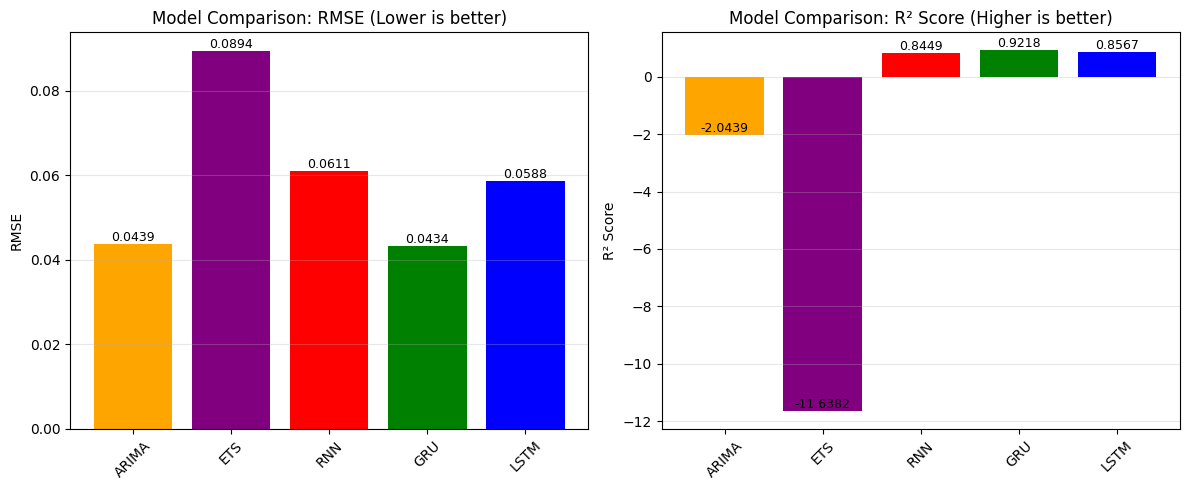

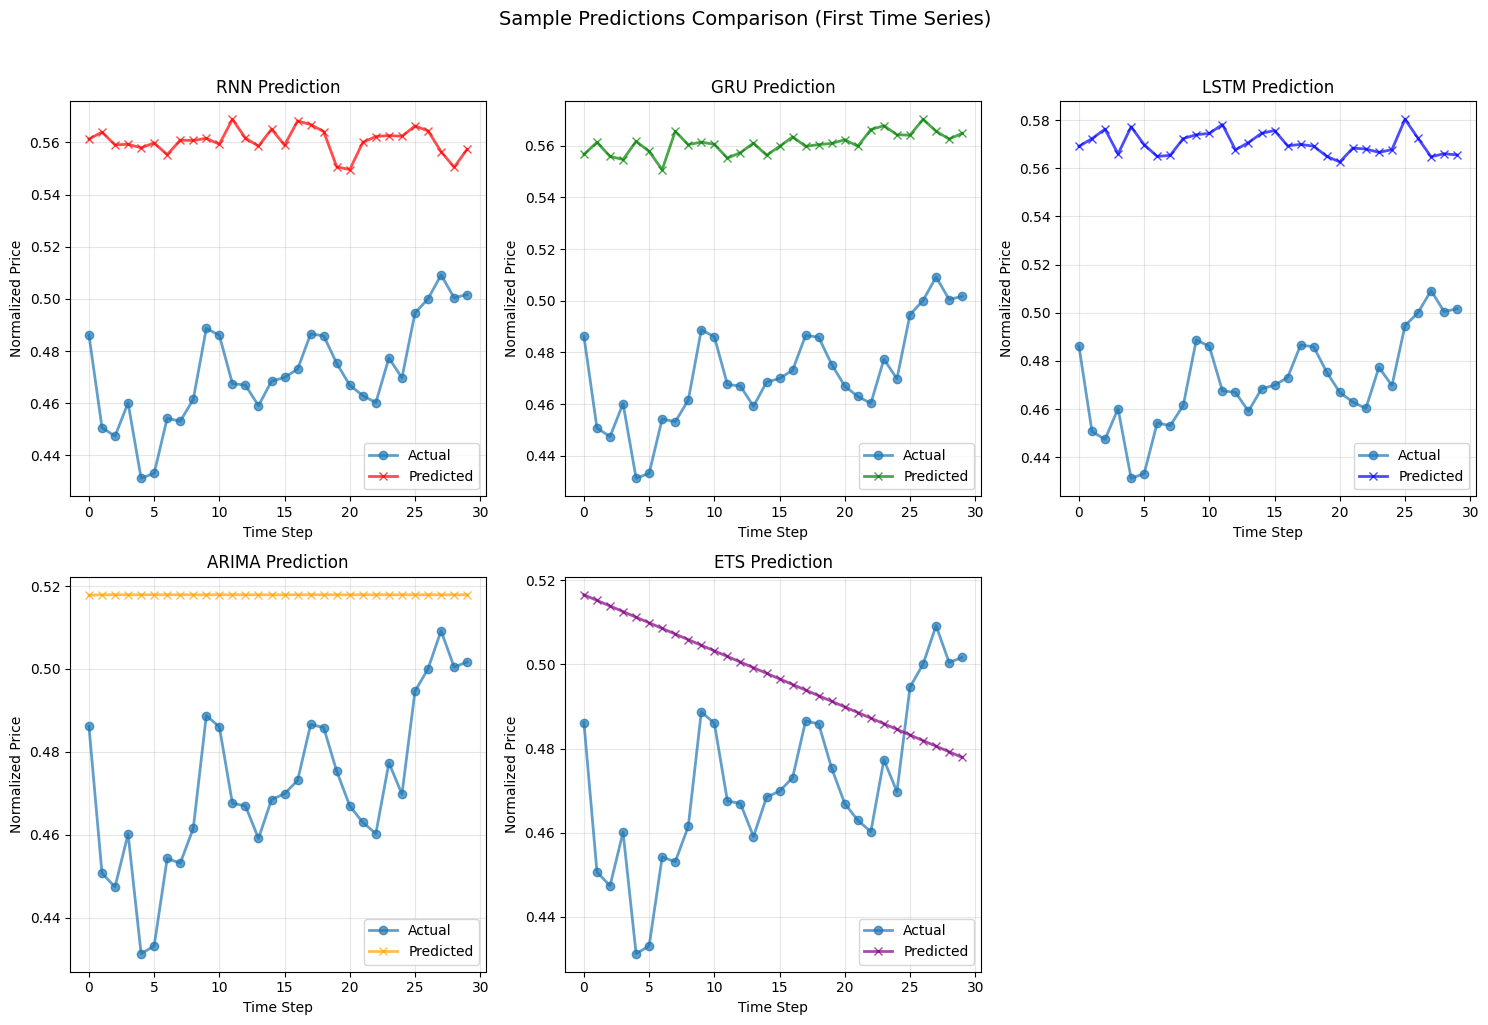


EXECUTION COMPLETE

Models trained and evaluated:
- Baseline models: ['ARIMA', 'ETS']
- Neural networks: ['RNN', 'GRU', 'LSTM']

Total comparison models: 5
Best model: GRU


In [25]:
# ============================================================================
# 1. UPDATED STATSMODELS BASELINE FUNCTION (FIXED)
# ============================================================================

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

def run_statsmodels_baseline(X_test, y_test, scaler=None):
    """
    Use statsmodels directly for baseline models
    Returns: Dictionary with predictions and metrics
    """
    print("="*60)
    print("USING STATSMODELS DIRECTLY")
    print("="*60)
    
    X_test_np = X_test.numpy().squeeze(-1)  # [batch, seq_len]
    y_test_np = y_test.numpy().squeeze(-1)  # [batch, horizon]
    
    results = {}
    n_series = min(10, len(X_test_np))  # Test on first 10 series only (for speed)
    
    # Store actual values for comparison (first n_series)
    actual_array = y_test_np[:n_series, :30]
    
    # ARIMA Baseline
    print("\n1. ARIMA model:")
    arima_predictions = []
    arima_success_count = 0
    
    for i in range(n_series):
        try:
            # Use the last 60 days to predict next 30 days
            train_data = X_test_np[i]
            
            # Fit ARIMA(1,1,1) - simple model
            model = ARIMA(train_data, order=(1, 1, 1))
            model_fit = model.fit()
            forecast = model_fit.forecast(steps=30)
            
            arima_predictions.append(forecast)
            arima_success_count += 1
            
            if (i + 1) % 5 == 0:
                print(f"  Processed {i+1}/{n_series} series")
                
        except Exception as e:
            # Fill with NaN if model fails
            arima_predictions.append(np.full(30, np.nan))
            print(f"  Series {i+1}: ARIMA failed")
    
    # Calculate ARIMA metrics
    if arima_success_count > 0:
        arima_array = np.array(arima_predictions)
        
        # Remove NaN predictions for metric calculation
        valid_mask = ~np.isnan(arima_array).any(axis=1)
        if valid_mask.sum() > 0:
            valid_arima = arima_array[valid_mask]
            valid_actual = actual_array[valid_mask]
            
            rmse = np.sqrt(np.mean((valid_arima - valid_actual) ** 2))
            mae = np.mean(np.abs(valid_arima - valid_actual))
            
            # R² score
            ss_res = np.sum((valid_actual - valid_arima) ** 2)
            ss_tot = np.sum((valid_actual - np.mean(valid_actual)) ** 2)
            r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
            
            results['ARIMA'] = {
                'predictions': arima_array,
                'actuals': actual_array,
                'metrics': {
                    'RMSE': rmse,
                    'MAE': mae,
                    'R²': r2,
                    'num_series': valid_mask.sum()
                }
            }
            
            print(f"ARIMA Results:")
            print(f"  RMSE: {rmse:.6f}")
            print(f"  MAE:  {mae:.6f}")
            print(f"  R²:   {r2:.6f}")
            print(f"  Successfully evaluated {valid_mask.sum()}/{n_series} series")
    else:
        print("ARIMA: Failed to evaluate any series")
    
    # Exponential Smoothing (ETS) Baseline
    print("\n2. Exponential Smoothing (ETS):")
    ets_predictions = []
    ets_success_count = 0
    
    for i in range(n_series):
        try:
            train_data = X_test_np[i]
            
            # Fit ETS model (additive trend, no seasonality)
            model = ExponentialSmoothing(train_data, trend='add', seasonal=None)
            model_fit = model.fit()
            forecast = model_fit.forecast(steps=30)
            
            ets_predictions.append(forecast)
            ets_success_count += 1
            
            if (i + 1) % 5 == 0:
                print(f"  Processed {i+1}/{n_series} series")
                
        except Exception as e:
            ets_predictions.append(np.full(30, np.nan))
            print(f"  Series {i+1}: ETS failed")
    
    # Calculate ETS metrics
    if ets_success_count > 0:
        ets_array = np.array(ets_predictions)
        
        # Remove NaN predictions
        valid_mask = ~np.isnan(ets_array).any(axis=1)
        if valid_mask.sum() > 0:
            valid_ets = ets_array[valid_mask]
            valid_actual = actual_array[valid_mask]
            
            rmse = np.sqrt(np.mean((valid_ets - valid_actual) ** 2))
            mae = np.mean(np.abs(valid_ets - valid_actual))
            
            # R² score
            ss_res = np.sum((valid_actual - valid_ets) ** 2)
            ss_tot = np.sum((valid_actual - np.mean(valid_actual)) ** 2)
            r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
            
            results['ETS'] = {
                'predictions': ets_array,
                'actuals': actual_array,
                'metrics': {
                    'RMSE': rmse,
                    'MAE': mae,
                    'R²': r2,
                    'num_series': valid_mask.sum()
                }
            }
            
            print(f"ETS Results:")
            print(f"  RMSE: {rmse:.6f}")
            print(f"  MAE:  {mae:.6f}")
            print(f"  R²:   {r2:.6f}")
            print(f"  Successfully evaluated {valid_mask.sum()}/{n_series} series")
    else:
        print("ETS: Failed to evaluate any series")
    
    return results

# ============================================================================
# 2. UPDATED MAIN FUNCTION (SIMPLIFIED)
# ============================================================================

def main():
    print("Data shapes:")
    print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
    print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")
    
    # ================================================
    # 1. RUN BASELINE MODELS
    # ================================================
    print("\n" + "="*60)
    print("PHASE 1: BASELINE MODELS (Statsmodels)")
    print("="*60)
    
    baseline_results = run_statsmodels_baseline(X_test, y_test, scaler)
    
    # ================================================
    # 2. RUN NEURAL NETWORK MODELS
    # ================================================
    print("\n" + "="*60)
    print("PHASE 2: NEURAL NETWORK MODELS")
    print("="*60)
    
    models_to_train = {
        'RNN': SimpleRNNModel(input_len=60, output_len=30),
        'GRU': SimpleGRUModel(input_len=60, output_len=30),
        'LSTM': SimpleLSTMModel(input_len=60, output_len=30)
    }
    
    nn_results = {}
    
    for model_name, model in models_to_train.items():
        print(f"\nTraining {model_name}...")
        trained_model, train_losses, test_losses, y_pred_test = train_model(
            model=model,
            model_name=model_name,
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test,
            n_epochs=200,  # Reduced for testing
            lr=0.001,
            batch_size=32,
            patience=30
        )
        
        # Calculate metrics
        with torch.no_grad():
            test_rmse = torch.sqrt(nn.MSELoss()(y_pred_test, y_test)).item()
            
            # Calculate R²
            y_test_np = y_test.cpu().numpy()
            y_pred_np = y_pred_test.cpu().numpy()
            
            ss_res = np.sum((y_test_np - y_pred_np) ** 2)
            ss_tot = np.sum((y_test_np - np.mean(y_test_np)) ** 2)
            r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
        
        nn_results[model_name] = {
            'model': trained_model,
            'train_losses': train_losses,
            'test_losses': test_losses,
            'predictions': y_pred_test,
            'metrics': {
                'RMSE': test_rmse,
                'R²': r2,
                'num_series': len(y_test)
            }
        }
        
        print(f"{model_name} Results:")
        print(f"  RMSE: {test_rmse:.6f}")
        print(f"  R²:   {r2:.6f}")
    
    # ================================================
    # 3. COMPARE ALL MODELS
    # ================================================
    print("\n" + "="*60)
    print("FINAL COMPARISON: ALL MODELS")
    print("="*60)
    
    # Create comparison table
    comparison_data = []
    
    print("\nModel Performance Comparison:")
    print("-" * 80)
    print(f"{'Model':<15} {'RMSE':<15} {'R²':<15} {'Series Evaluated':<20}")
    print("-" * 80)
    
    # Add baseline models
    for name, result in baseline_results.items():
        if 'metrics' in result:
            metrics = result['metrics']
            comparison_data.append({
                'Model': name,
                'RMSE': metrics['RMSE'],
                'R²': metrics.get('R²', 0),
                'Series': metrics['num_series']
            })
            print(f"{name:<15} {metrics['RMSE']:<15.6f} {metrics.get('R²', 0):<15.6f} {metrics['num_series']:<20}")
    
    # Add neural network models
    for name, result in nn_results.items():
        metrics = result['metrics']
        comparison_data.append({
            'Model': name,
            'RMSE': metrics['RMSE'],
            'R²': metrics['R²'],
            'Series': metrics['num_series']
        })
        print(f"{name:<15} {metrics['RMSE']:<15.6f} {metrics['R²']:<15.6f} {metrics['num_series']:<20}")
    
    print("-" * 80)
    
    # Find best model
    comparison_df = pd.DataFrame(comparison_data)
    best_model_row = comparison_df.loc[comparison_df['RMSE'].idxmin()]
    print(f"\nBest model by RMSE: {best_model_row['Model']}")
    print(f"RMSE: {best_model_row['RMSE']:.6f}")
    print(f"R²: {best_model_row['R²']:.6f}")
    
    # ================================================
    # 4. VISUALIZE RESULTS
    # ================================================
    
    # Plot 1: RMSE Comparison
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    colors = ['orange', 'purple', 'red', 'green', 'blue']
    models = comparison_df['Model'].tolist()
    rmses = comparison_df['RMSE'].tolist()
    
    bars = plt.bar(models, rmses, color=colors[:len(models)])
    plt.title('Model Comparison: RMSE (Lower is better)')
    plt.ylabel('RMSE')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, axis='y')
    
    for bar, rmse in zip(bars, rmses):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{rmse:.4f}', ha='center', va='bottom', fontsize=9)
    
    # Plot 2: R² Comparison
    plt.subplot(1, 2, 2)
    r2_scores = comparison_df['R²'].tolist()
    
    bars = plt.bar(models, r2_scores, color=colors[:len(models)])
    plt.title('Model Comparison: R² Score (Higher is better)')
    plt.ylabel('R² Score')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, axis='y')
    
    for bar, r2 in zip(bars, r2_scores):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{r2:.4f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Plot 3: Sample Predictions
    plot_sample_predictions(baseline_results, nn_results, y_test)
    
    return baseline_results, nn_results, comparison_df

# ============================================================================
# 3. UPDATED VISUALIZATION FUNCTION
# ============================================================================

def plot_sample_predictions(baseline_results, nn_results, y_test, sample_idx=0):
    """
    Plot sample predictions from all models
    """
    plt.figure(figsize=(15, 10))
    
    # Plot neural network predictions
    nn_models = list(nn_results.keys())
    for idx, model_name in enumerate(nn_models):
        plt.subplot(2, 3, idx+1)
        
        result = nn_results[model_name]
        actual = y_test[sample_idx, :, 0].cpu().numpy()
        predicted = result['predictions'][sample_idx, :, 0].cpu().numpy()
        
        colors = {'RNN': 'red', 'GRU': 'green', 'LSTM': 'blue'}
        
        plt.plot(actual, label='Actual', marker='o', alpha=0.7, linewidth=2)
        plt.plot(predicted, label='Predicted', marker='x', 
                color=colors.get(model_name, 'black'), alpha=0.7, linewidth=2)
        plt.xlabel('Time Step')
        plt.ylabel('Normalized Price')
        plt.title(f'{model_name} Prediction')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    # Plot baseline predictions
    baseline_models = list(baseline_results.keys())
    for idx, model_name in enumerate(baseline_models):
        plt.subplot(2, 3, idx+4)
        
        result = baseline_results[model_name]
        actual = result['actuals'][sample_idx]
        predicted = result['predictions'][sample_idx]
        
        colors = {'ARIMA': 'orange', 'ETS': 'purple'}
        
        plt.plot(actual, label='Actual', marker='o', alpha=0.7, linewidth=2)
        plt.plot(predicted, label='Predicted', marker='x', 
                color=colors.get(model_name, 'brown'), alpha=0.7, linewidth=2)
        plt.xlabel('Time Step')
        plt.ylabel('Normalized Price')
        plt.title(f'{model_name} Prediction')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    plt.suptitle('Sample Predictions Comparison (First Time Series)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# ============================================================================
# 4. RUN THE COMPLETE PIPELINE
# ============================================================================

print("Starting complete model comparison...")
print("="*60)

# Run the main function
baseline_results, nn_results, comparison_df = main()

# Print final summary
print("\n" + "="*60)
print("EXECUTION COMPLETE")
print("="*60)
print(f"\nModels trained and evaluated:")
print(f"- Baseline models: {list(baseline_results.keys())}")
print(f"- Neural networks: {list(nn_results.keys())}")
print(f"\nTotal comparison models: {len(comparison_df)}")
print(f"Best model: {comparison_df.loc[comparison_df['RMSE'].idxmin(), 'Model']}")